# POF 2017-2018 — Education and Household Debt

**TCC — Universidade de São Paulo**

This notebook is intentionally *thin*: it only **imports and calls** the
`pof` package (in `src/pof/`). All data-reading, aggregation, debt construction,
modelling and plotting logic lives in the package, with classes and functions
that are tested and documented. No transformation logic is defined here.

**Pipeline**
1. Configure the run (`AnalysisConfig`)
2. Load the POF tables (`PofReader`)
3. Build the UC-level analytical dataset (`AnalyticalDataset`)
4. Descriptive analysis + figures (`DescriptivePlots`)
5. Econometric models (`DebtModels`)

See `docs/` for the project goal, the dictionary/CSV findings, the current-state
review and the architecture rationale.

## 1. Setup — import the package and configure the run

In [1]:
import sys
from pathlib import Path

# make the local `pof` package importable
SRC = Path("src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from pof import default_config, DEBT_CATEGORIES
from pof.io import PofReader
from pof.dataset import AnalyticalDataset
from pof.plots import DescriptivePlots
from pof.models import DebtModels

config = default_config()
config.ensure_dirs()
print("Debt categories:", list(DEBT_CATEGORIES))
print("Debt codes in use:", config.all_debt_codes())

Debt categories: ['interest_and_fees', 'principal_repayment', 'default_charges', 'late_payment_penalties']
Debt codes in use: ['2600101', '2600201', '4800201', '4802201', '1000201', '1000801', '1000901', '1001001', '1001101', '1001201', '1203201', '1203301']


## 2. Load the POF tables

`PofReader` reads each table either from the Parquet cache or, on first run, from
the raw fixed-width TXT using the byte layout in the Excel dictionary. It applies
the **PESO_FINAL / decimal-point scaling fix** described in `docs/`.

In [2]:
reader = PofReader(config)
tables = reader.load_all()
{name: df.shape for name, df in tables.items()}

[MORADOR] read from parquet cache -> (178431, 56)


[DESPESA_INDIVIDUAL] read from parquet cache -> (1836032, 25)
[DESPESA_COLETIVA] read from parquet cache -> (478572, 27)


{'MORADOR': (178431, 56),
 'DESPESA_INDIVIDUAL': (1836032, 25),
 'DESPESA_COLETIVA': (478572, 27)}

## 3. Build the analytical dataset (one row per consumption unit)

`AnalyticalDataset` aggregates people into UCs with **population-weighted**
schooling/age statistics, builds **deflated + annualized** debt per UC by
economic category, and derives `debt_to_income`, `has_debt`, `log_debt`, etc.

In [3]:
dataset = AnalyticalDataset(config)
df = dataset.build(tables)

print(f"UCs: {df.height:,}")
print(f"Weighted households: {df.select(pl.col('weight').sum()).item():,.0f}")
print(f"UCs with debt: {df.filter(pl.col('has_debt') == 1).height:,} "
      f"({df.select(pl.col('has_debt').mean()).item()*100:.1f}%)")
df.head()

UCs: 57,965
Weighted households: 68,941,658
UCs with debt: 3,831 (6.6%)


COD_UPA,NUM_DOM,NUM_UC,UF,education_min,education_max,education_mean,education_median,education_mode,instruction_mode,instruction_median,age_mean,age_median,n_members_aggregated,head_sex,household_income,weight,total_debt,debt_interest_and_fees,debt_principal_repayment,debt_default_charges,debt_late_payment_penalties,debt_to_income,has_debt,log_debt,log_income,head_is_woman,education_band
str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,i8,f64,f64,i8,enum
"""170011343""","""8""","""1""","""17""",12,12,12,12,12,5,5,33,33,1,"""2""",1339.47,366.987164,0.0,0.0,0.0,0.0,0.0,0.0,0,null,7.200029,1,"""Higher education (11+)"""
"""420021483""","""2""","""1""","""42""",5,6,6,6,5,2,2,54,54,2,"""2""",3780.74,307.875739,0.0,0.0,0.0,0.0,0.0,0.0,0,null,8.237675,1,"""Lower secondary (4-8)"""
"""170009050""","""8""","""1""","""17""",9,12,10,10,9,3,4,27,27,2,"""1""",1466.43,462.230032,0.0,0.0,0.0,0.0,0.0,0.0,0,null,7.290586,0,"""Upper secondary (8-11)"""
"""260071690""","""8""","""1""","""26""",5,12,7,5,5,2,2,38,47,3,"""1""",976.52,1265.511041,0.0,0.0,0.0,0.0,0.0,0.0,0,null,6.883995,0,"""Lower secondary (4-8)"""
"""330036751""","""11""","""1""","""33""",6,10,8,8,6,2,3,37,37,2,"""1""",2998.21,1871.297409,0.0,0.0,0.0,0.0,0.0,0.0,0,null,8.005771,0,"""Lower secondary (4-8)"""


### 3.1 Sanity checks (population totals and income)

In [4]:
pdf = df.to_pandas()

checks = {
    "weighted_households": float(np.sum(pdf["weight"])),
    "median_income_R$": float(pdf["household_income"].median()),
    "mean_income_R$": float(pdf["household_income"].mean()),
    "share_with_debt_%": float(pdf["has_debt"].mean() * 100),
    "median_annual_debt_debtors_R$": float(pdf.loc[pdf.has_debt == 1, "total_debt"].median()),
}
pd.Series(checks).round(2)

weighted_households              68941657.61
median_income_R$                     2925.09
mean_income_R$                       4674.97
share_with_debt_%                       6.61
median_annual_debt_debtors_R$         667.56
dtype: float64

## 4. Descriptive analysis

All bars are **population-weighted**. Figures are saved as PNG under
`figures/` and also shown inline.

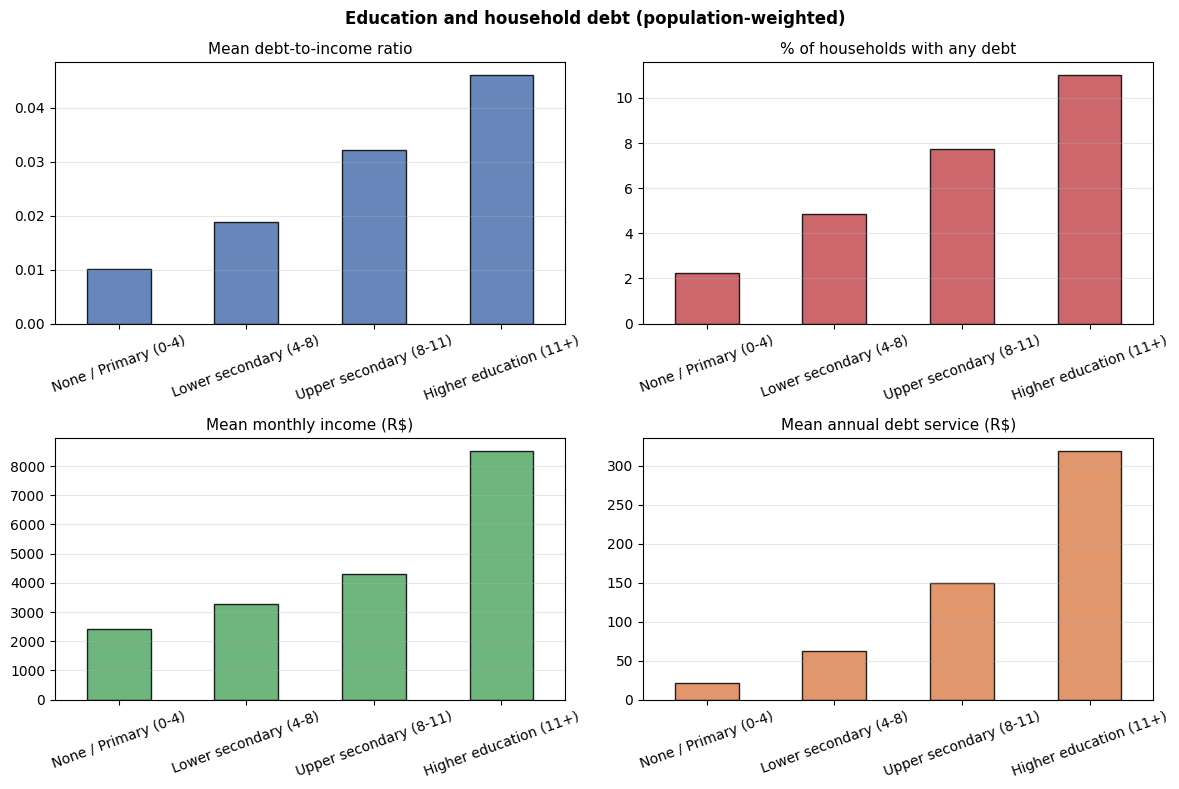

In [5]:
plots = DescriptivePlots(config)

fig = plots.debt_burden_by_education(pdf)
plt.show()

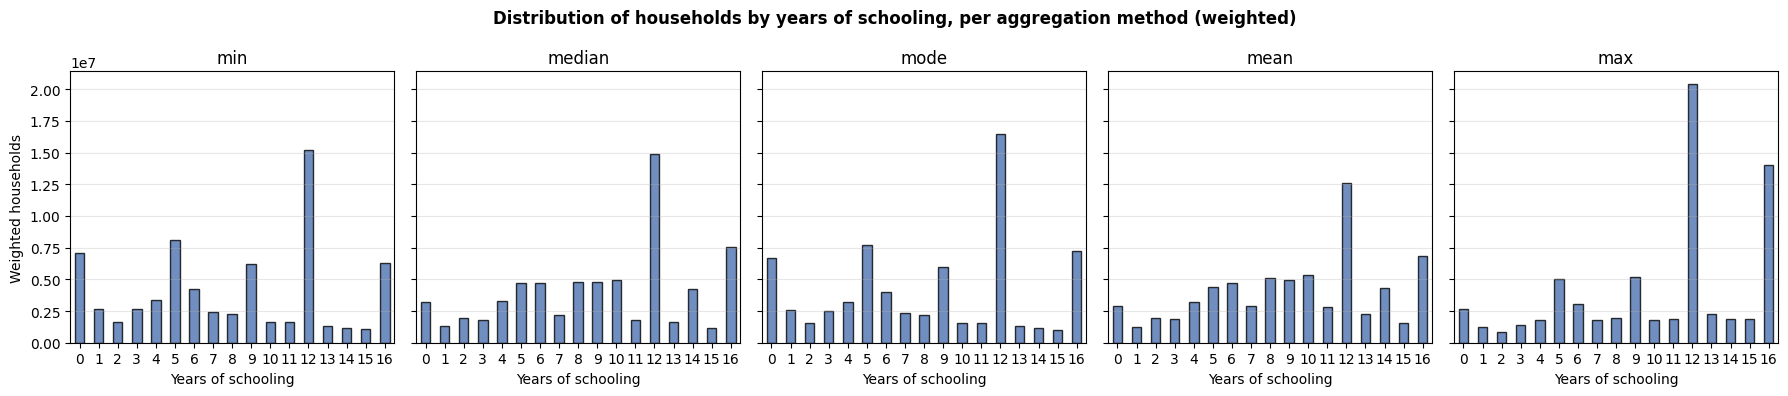

In [6]:
fig = plots.education_distribution(pdf)
plt.show()

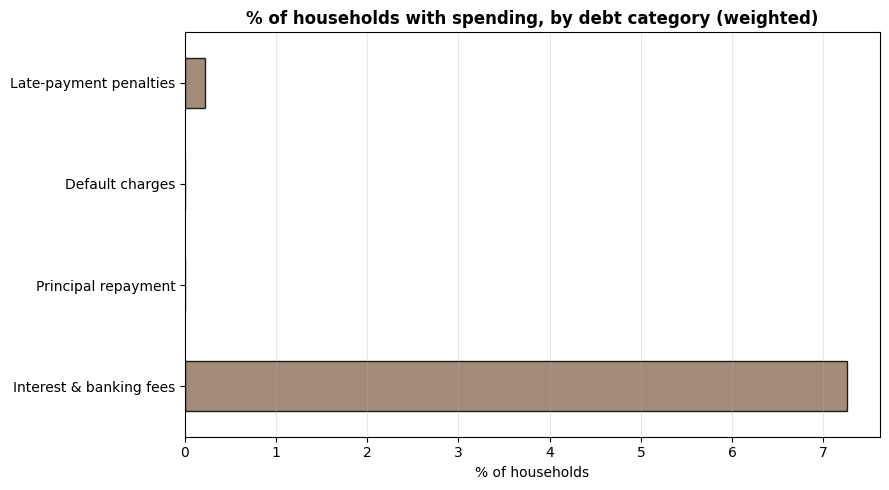

In [7]:
fig = plots.debt_by_category(pdf)
plt.show()

### 4.1 Weighted summary by education band

In [8]:
def wmean(s, w):
    m = s.notna() & w.notna() & (w > 0)
    return np.average(s[m], weights=w[m]) if m.any() else np.nan

rows = []
for band in config.education_labels:
    sub = pdf[pdf["education_band"] == band]
    rows.append({
        "education_band": band,
        "n_ucs": len(sub),
        "mean_income": wmean(sub["household_income"], sub["weight"]),
        "share_with_debt_%": wmean(sub["has_debt"], sub["weight"]) * 100,
        "mean_debt_to_income": wmean(sub["debt_to_income"], sub["weight"]),
    })
pd.DataFrame(rows).round(4)

,education_band,n_ucs,mean_income,share_with_debt_%,mean_debt_to_income
0,None / Primary (0-4),11638,2410.7336,2.2425,0.0101
1,Lower secondary (4-8),15699,3284.3491,4.8421,0.0188
2,Upper secondary (8-11),10730,4309.8441,7.7219,0.0321
3,Higher education (11+),19898,8521.4180,11.0227,0.0462


## 5. Econometric models

Two-part (hurdle) approach plus a relative-burden regression, all
**population-weighted** with HC3-robust errors for the OLS parts:

- **logit_access** — P(has any debt): does schooling change *access* to credit?
- **ols_log_volume** — log(debt) | debt>0: does schooling change the *volume*?
- **ols_burden** — debt/income (winsorized): does schooling change the *relative burden*?

In [9]:
models = DebtModels(config)
results = models.fit_all(pdf)
results_df = DebtModels.to_frame(results)
results_df.to_csv(config.outputs_dir / "model_summary.csv", index=False)
results_df

,model,focal_term,coef,std_err,p_value,nobs,odds_ratio,rsquared
0,logit_access,education_mean,0.099599,0.000303,0.000000e+00,57965,1.104727,NaN
1,ols_log_volume,education_mean,0.056340,0.022219,1.122104e-02,3831,NaN,0.140702
2,ols_burden,education_mean,0.001580,0.000253,3.912002e-10,57965,NaN,0.012369


### Interpretation

The focal coefficient is on `education_mean` (mean years of schooling among adults
with income — the measure most correlated with income).

- `logit_access`: odds-ratio > 1 ⇒ more schooling raises the probability of holding debt (credit access).
- `ols_log_volume`: positive ⇒ given access, more schooling is associated with a larger debt amount.
- `ols_burden`: positive ⇒ more schooling raises the share of income committed to debt service.

Read the three together for the full narrative — see `docs/03_current_state_and_next_steps.md`.